# Cross-System Latency Analysis

Correlates **poc-deepgram** ground-truth audio timestamps with **Genesys Cloud** transcription delivery times to measure true end-to-end transcription pipeline latency.

## What We're Measuring

The **true latency** captures the full Genesys transcription pipeline — from the moment words are spoken to when the transcribed text arrives at our application:

```
Speaker's voice
  → [1] Genesys captures audio from the call (VoIP/WebRTC stream)
  → [2] Genesys STT engine (r2d2) processes the audio into text
  → [3] Genesys endpointing decides the utterance is complete (isFinal=true)
  → [4] WebSocket notification delivered to notifications-spike
```

**Stage 1 — Audio Capture**: Genesys receives the raw audio stream from the call. This includes network transport from the caller's phone/WebRTC client to Genesys Cloud.

**Stage 2 — STT Processing**: The Genesys r2d2 engine converts audio to text. This includes acoustic model inference, language model scoring, and word-level confidence/timing computation.

**Stage 3 — Endpointing**: Genesys holds partial transcripts until it determines the speaker has finished an utterance. This is the biggest variable — Genesys may combine multiple sentences into a single `isFinal=true` event, adding wait time but producing more complete transcripts. Deepgram typically endpoints faster (300ms silence threshold), which is why it splits utterances that Genesys combines.

**Stage 4 — WebSocket Delivery**: The final transcript event is pushed through the Genesys notifications API WebSocket channel to our application. This includes serialization, routing, and network latency.

## Formula

```
true_latency = genesys_receivedAt - deepgram_audio_wall_clock_end
```

**Ground truth**: poc-deepgram captures the same call audio independently via BlackHole, providing wall-clock timestamps for when speech was actually heard through the speakers.

**Measurement point**: notifications-spike records `receivedAt` (via `time.time()`) when each Genesys transcription event arrives.

Both apps run on the same machine — no clock synchronization issues.

See `docs/cross_system_latency_plan.md` for the full implementation plan and `docs/manual_test_directions.md` for setup instructions.

---
## Module 1: Setup & Configuration

In [1]:
# === SET NUMBER OF RECENT SESSIONS TO CORRELATE ===
NUM_RECENT = 6  # Change this to match N most recent file pairs

In [2]:
import json
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

# Add parent directory to path so we can import scripts.correlate_latency
REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from scripts.correlate_latency import (
    correlate,
    load_deepgram_session,
    load_genesys_conversation,
    match_utterances,
    CorrelationResult,
)

# === CONFIGURE THESE PATHS ===
# Point to your poc-deepgram session file and the matching Genesys conversation JSONL
DEEPGRAM_SESSION = REPO_ROOT / ".." / "poc-deepgram" / "results" / "REPLACE_ME.json"
GENESYS_CONVERSATION = REPO_ROOT / "conversation_events" / "REPLACE_ME.jsonl"

# Or auto-detect the most recent files
DEEPGRAM_RESULTS_DIR = (REPO_ROOT / ".." / "poc-deepgram" / "results").resolve()
GENESYS_EVENTS_DIR = (REPO_ROOT / "conversation_events").resolve()

OUTPUT_DIR = REPO_ROOT / "analysis_results" / "cross_system"
SAVE_DPI = 300
SIMILARITY_THRESHOLD = 0.55

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Repo root: {REPO_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")

Repo root: /Users/xnxn040/PycharmProjects/notifications-spike
Output dir: /Users/xnxn040/PycharmProjects/notifications-spike/analysis_results/cross_system


---
## Module 2: Auto-Detect & Load Data

Enter the number of most recent sessions to correlate. The notebook matches Deepgram sessions to Genesys conversations by overlapping time windows.

In [3]:
# List available files from both systems (most recent first)
dg_files = sorted(DEEPGRAM_RESULTS_DIR.glob("*.json"), key=lambda f: f.stat().st_mtime, reverse=True)
gn_files = sorted(GENESYS_EVENTS_DIR.glob("*.jsonl"), key=lambda f: f.stat().st_mtime, reverse=True)

print(f"Available Deepgram sessions: {len(dg_files)}")
for i, f in enumerate(dg_files[:10]):
    data = json.loads(f.read_text())
    session = data.get("session", {})
    print(f"  [{i}] {f.name}  ({session.get('started_at', '?')} — {session.get('duration_seconds', '?')}s)")

print(f"\nAvailable Genesys conversations: {len(gn_files)}")
for i, f in enumerate(gn_files[:10]):
    lines = f.read_text().strip().splitlines()
    if lines:
        first = json.loads(lines[0])
        ts = datetime.fromtimestamp(first["receivedAt"], tz=timezone.utc)
        print(f"  [{i}] {f.name}  ({ts:%Y-%m-%d %H:%M} — {len(lines)} events)")
    else:
        print(f"  [{i}] {f.name}  (empty)")

Available Deepgram sessions: 6
  [0] nova-3_2026-03-18T19-24-15Z.json  (2026-03-18T19:24:15.635422+00:00 — 105.7s)
  [1] nova-3_2026-03-18T19-17-36Z.json  (2026-03-18T19:17:36.287680+00:00 — 203.3s)
  [2] nova-3_2026-03-18T19-10-50Z.json  (2026-03-18T19:10:50.321937+00:00 — 274.1s)
  [3] nova-3_2026-03-18T19-07-21Z.json  (2026-03-18T19:07:21.038355+00:00 — 95.9s)
  [4] nova-3_2026-03-18T19-02-32Z.json  (2026-03-18T19:02:32.626903+00:00 — 197.2s)
  [5] nova-3_2026-03-18T18-54-36Z.json  (2026-03-18T18:54:36.988718+00:00 — 173.7s)

Available Genesys conversations: 6
  [0] 23c14252-468b-46fa-b621-e2c9326a2722.jsonl  (2026-03-18 19:24 — 6 events)
  [1] 2fe10c64-f7c6-449c-a26c-c85b9a50ca6d.jsonl  (2026-03-18 19:18 — 20 events)
  [2] f536b591-490c-499d-8596-ce4ec1f45d62.jsonl  (2026-03-18 19:11 — 34 events)
  [3] ef34bf63-6153-4bed-8f7f-da7844099828.jsonl  (2026-03-18 19:07 — 9 events)
  [4] 158d6fb9-9fc8-4312-a633-4929a68f5eb1.jsonl  (2026-03-18 19:02 — 34 events)
  [5] bf4c94bf-c655-4845-82

In [4]:
# Take the N most recent files from each system
dg_recent = dg_files[:NUM_RECENT]
gn_recent = gn_files[:NUM_RECENT]

def get_dg_time_range(path):
    """Extract session start/end times from a Deepgram session JSON."""
    data = json.loads(path.read_text())
    session = data.get("session", {})
    started = session.get("started_at", "")
    ended = session.get("ended_at", "")
    start_ts = datetime.fromisoformat(started).timestamp() if started else 0
    end_ts = datetime.fromisoformat(ended).timestamp() if ended else float("inf")
    return start_ts, end_ts

def get_gn_time_range(path):
    """Extract first/last receivedAt from a Genesys conversation JSONL."""
    lines = path.read_text().strip().splitlines()
    if not lines:
        return 0, 0
    timestamps = [json.loads(line)["receivedAt"] for line in lines]
    return min(timestamps), max(timestamps)

# Auto-match by overlapping time windows
matched_pairs = []
used_gn = set()

for dg_path in dg_recent:
    dg_start, dg_end = get_dg_time_range(dg_path)
    best_gn = None
    best_overlap = 0
    for j, gn_path in enumerate(gn_recent):
        if j in used_gn:
            continue
        gn_start, gn_end = get_gn_time_range(gn_path)
        # Compute overlap
        overlap_start = max(dg_start, gn_start)
        overlap_end = min(dg_end, gn_end)
        overlap = max(0, overlap_end - overlap_start)
        if overlap > best_overlap:
            best_overlap = overlap
            best_gn = j
    if best_gn is not None:
        matched_pairs.append((dg_path, gn_recent[best_gn]))
        used_gn.add(best_gn)

print(f"Auto-matched {len(matched_pairs)} session pair(s):")
for dg_p, gn_p in matched_pairs:
    print(f"  Deepgram: {dg_p.name}  <-->  Genesys: {gn_p.name}")

Auto-matched 6 session pair(s):
  Deepgram: nova-3_2026-03-18T19-24-15Z.json  <-->  Genesys: 23c14252-468b-46fa-b621-e2c9326a2722.jsonl
  Deepgram: nova-3_2026-03-18T19-17-36Z.json  <-->  Genesys: 2fe10c64-f7c6-449c-a26c-c85b9a50ca6d.jsonl
  Deepgram: nova-3_2026-03-18T19-10-50Z.json  <-->  Genesys: f536b591-490c-499d-8596-ce4ec1f45d62.jsonl
  Deepgram: nova-3_2026-03-18T19-07-21Z.json  <-->  Genesys: ef34bf63-6153-4bed-8f7f-da7844099828.jsonl
  Deepgram: nova-3_2026-03-18T19-02-32Z.json  <-->  Genesys: 158d6fb9-9fc8-4312-a633-4929a68f5eb1.jsonl
  Deepgram: nova-3_2026-03-18T18-54-36Z.json  <-->  Genesys: bf4c94bf-c655-4845-82ad-56eabd726f90.jsonl


---
## Module 3: Correlation & Matching

In [5]:
# Run correlation across all matched pairs
all_results = []
pair_labels = []

for dg_path, gn_path in matched_pairs:
    pair_results = correlate(dg_path, gn_path, similarity_threshold=SIMILARITY_THRESHOLD)
    if pair_results:
        all_results.extend(pair_results)
        pair_labels.extend([f"{dg_path.stem} <-> {gn_path.stem}"] * len(pair_results))
        print(f"  {dg_path.name} <-> {gn_path.name}: {len(pair_results)} matched utterances")
    else:
        print(f"  {dg_path.name} <-> {gn_path.name}: no matches")

results = all_results
print(f"\nTotal matched utterance pairs: {len(results)}")

if not results:
    print("\nNo matches found. Check that:")
    print("  1. The files cover the same calls")
    print("  2. poc-deepgram captured the same audio Genesys transcribed")
    print("  3. The similarity threshold isn't too high (current: {SIMILARITY_THRESHOLD})")
else:
    df = pd.DataFrame([
        {
            "pair": label,
            "deepgram_transcript": r.deepgram_transcript,
            "genesys_transcript": r.genesys_transcript,
            "audio_wall_clock_end": r.audio_wall_clock_end,
            "genesys_received_at": r.genesys_received_at,
            "true_latency_s": r.true_latency_s,
            "true_latency_ms": r.true_latency_ms,
            "channel": r.channel,
            "similarity": r.similarity,
        }
        for r, label in zip(results, pair_labels)
    ])
    df["received_dt"] = pd.to_datetime(df["genesys_received_at"], unit="s", utc=True)
    df["audio_dt"] = pd.to_datetime(df["audio_wall_clock_end"], unit="s", utc=True)
    
    print(f"\nLatency range: {df['true_latency_ms'].min():.0f}ms — {df['true_latency_ms'].max():.0f}ms")
    print(f"Mean similarity: {df['similarity'].mean():.3f}")
    df.head()

  nova-3_2026-03-18T19-24-15Z.json <-> 23c14252-468b-46fa-b621-e2c9326a2722.jsonl: 1 matched utterances
  nova-3_2026-03-18T19-17-36Z.json <-> 2fe10c64-f7c6-449c-a26c-c85b9a50ca6d.jsonl: 15 matched utterances
  nova-3_2026-03-18T19-10-50Z.json <-> f536b591-490c-499d-8596-ce4ec1f45d62.jsonl: 23 matched utterances
  nova-3_2026-03-18T19-07-21Z.json <-> ef34bf63-6153-4bed-8f7f-da7844099828.jsonl: 8 matched utterances
  nova-3_2026-03-18T19-02-32Z.json <-> 158d6fb9-9fc8-4312-a633-4929a68f5eb1.jsonl: 28 matched utterances
  nova-3_2026-03-18T18-54-36Z.json <-> bf4c94bf-c655-4845-82ad-56eabd726f90.jsonl: 19 matched utterances

Total matched utterance pairs: 94

Latency range: -29618ms — 20365ms
Mean similarity: 0.798


---
## Module 4: Summary Statistics

In [6]:
if results:
    latencies_ms = df["true_latency_ms"]
    latencies_s = df["true_latency_s"]
    
    print("=" * 60)
    print("CROSS-SYSTEM LATENCY SUMMARY")
    print("=" * 60)
    print(f"  Matched pairs:    {len(df)}")
    print(f"  Mean latency:     {latencies_ms.mean():.0f} ms ({latencies_s.mean():.3f} s)")
    print(f"  Median latency:   {latencies_ms.median():.0f} ms")
    print(f"  Std deviation:    {latencies_ms.std():.0f} ms")
    print(f"  Min latency:      {latencies_ms.min():.0f} ms")
    print(f"  Max latency:      {latencies_ms.max():.0f} ms")
    print()
    
    for p in [0.50, 0.75, 0.90, 0.95, 0.99]:
        print(f"  p{int(p*100):02d}:             {latencies_ms.quantile(p):.0f} ms")
    
    # By channel
    channels = df["channel"].unique()
    if len(channels) > 1:
        print(f"\nBy Channel:")
        for ch in sorted(channels):
            ch_data = df[df["channel"] == ch]["true_latency_ms"]
            print(f"  {ch}: median={ch_data.median():.0f}ms, mean={ch_data.mean():.0f}ms, n={len(ch_data)}")

CROSS-SYSTEM LATENCY SUMMARY
  Matched pairs:    94
  Mean latency:     2430 ms (2.430 s)
  Median latency:   1710 ms
  Std deviation:    4677 ms
  Min latency:      -29618 ms
  Max latency:      20365 ms

  p50:             1710 ms
  p75:             2300 ms
  p90:             4627 ms
  p95:             10428 ms
  p99:             16430 ms


---
## Module 5: Visualizations

### Chart 1: True Latency Distribution

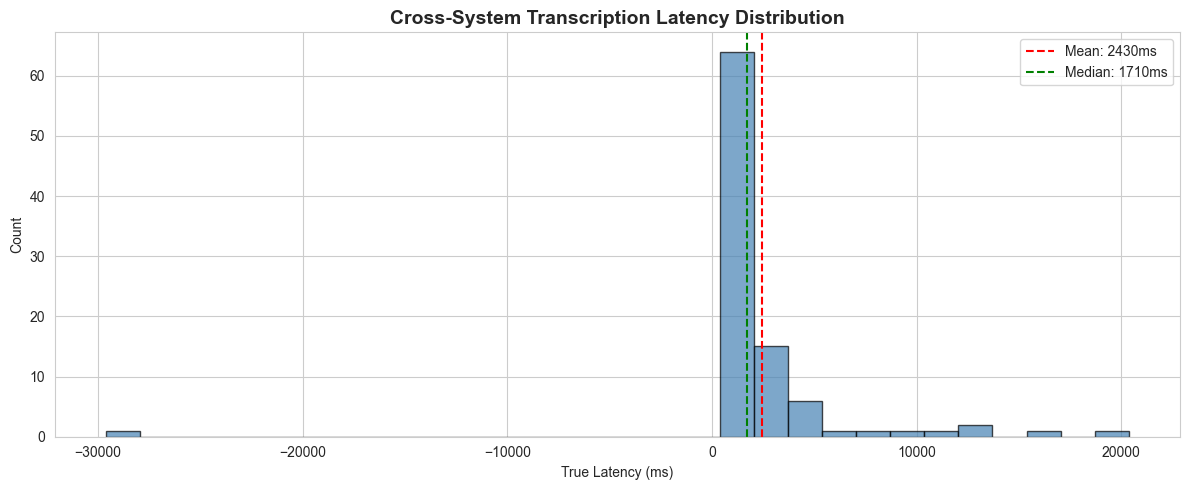

In [7]:
if results:
    fig, ax = plt.subplots(figsize=(12, 5))
    
    ax.hist(df["true_latency_ms"], bins=30, edgecolor="black", alpha=0.7, color="steelblue")
    ax.axvline(df["true_latency_ms"].mean(), color="red", linestyle="--", 
               label=f"Mean: {df['true_latency_ms'].mean():.0f}ms")
    ax.axvline(df["true_latency_ms"].median(), color="green", linestyle="--",
               label=f"Median: {df['true_latency_ms'].median():.0f}ms")
    ax.set_xlabel("True Latency (ms)")
    ax.set_ylabel("Count")
    ax.set_title("Cross-System Transcription Latency Distribution", fontsize=14, fontweight="bold")
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "cross_latency_distribution.png", dpi=SAVE_DPI, bbox_inches="tight")
    plt.show()

### Chart 2: Latency Timeline (scatter + trend)

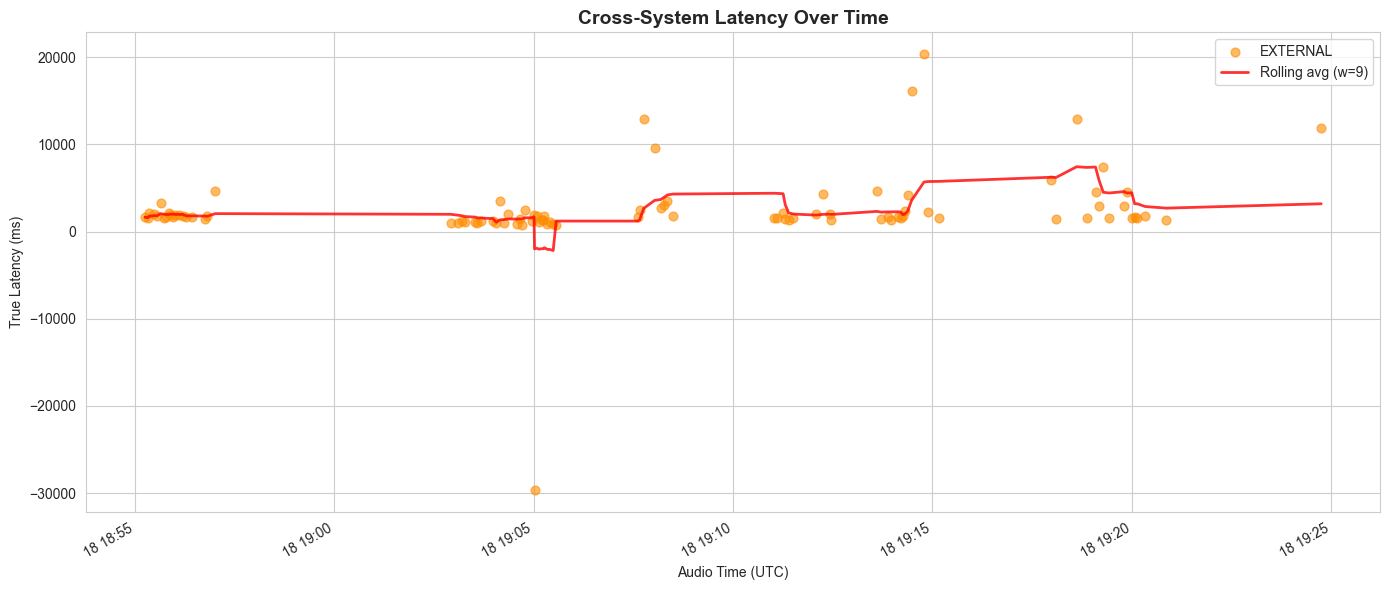

In [8]:
if results and len(df) > 1:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    for channel, color in [("INTERNAL", "steelblue"), ("EXTERNAL", "darkorange")]:
        mask = df["channel"] == channel
        if mask.any():
            subset = df[mask].sort_values("audio_dt")
            ax.scatter(subset["audio_dt"], subset["true_latency_ms"],
                       alpha=0.6, s=40, color=color, label=channel)
    
    # Rolling average trend
    df_sorted = df.sort_values("audio_dt")
    window = max(3, len(df_sorted) // 10)
    rolling = df_sorted["true_latency_ms"].rolling(window=window, min_periods=1).mean()
    ax.plot(df_sorted["audio_dt"].values, rolling.values, color="red", linewidth=2,
            alpha=0.8, label=f"Rolling avg (w={window})")
    
    ax.set_xlabel("Audio Time (UTC)")
    ax.set_ylabel("True Latency (ms)")
    ax.set_title("Cross-System Latency Over Time", fontsize=14, fontweight="bold")
    ax.legend()
    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "cross_latency_timeline.png", dpi=SAVE_DPI, bbox_inches="tight")
    plt.show()

### Chart 3: Latency by Channel (box plot)

In [9]:
if results and len(df["channel"].unique()) > 1:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    sns.boxplot(
        data=df, x="channel", y="true_latency_ms",
        palette={"INTERNAL": "steelblue", "EXTERNAL": "darkorange"},
        ax=ax, showfliers=True,
        flierprops={"marker": ".", "alpha": 0.3},
    )
    ax.set_xlabel("Channel")
    ax.set_ylabel("True Latency (ms)")
    ax.set_title("Cross-System Latency by Channel", fontsize=14, fontweight="bold")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "cross_latency_boxplot.png", dpi=SAVE_DPI, bbox_inches="tight")
    plt.show()

### Chart 4: Match Quality — Similarity vs Latency

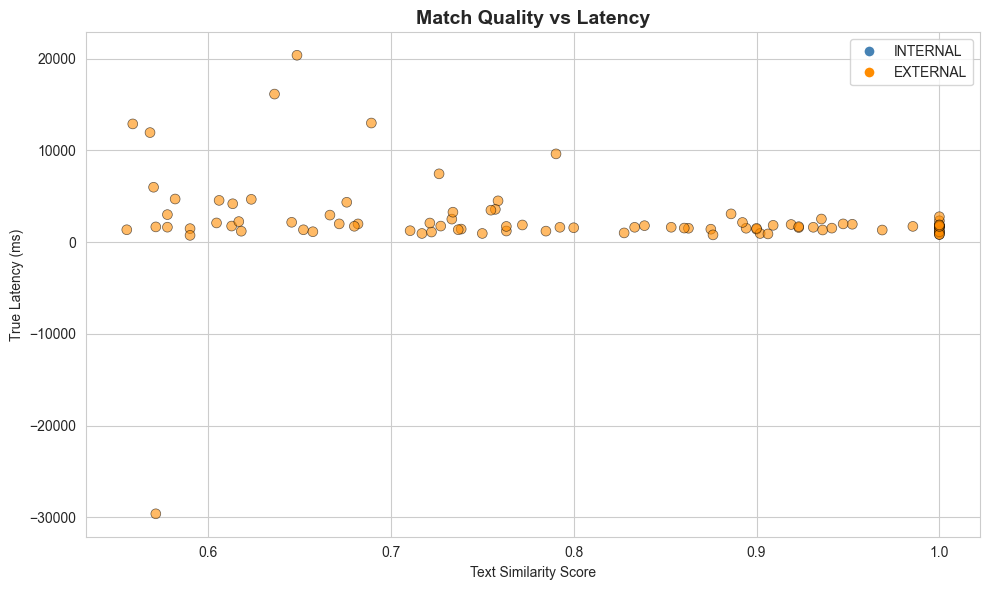

In [10]:
if results:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    scatter = ax.scatter(
        df["similarity"], df["true_latency_ms"],
        c=df["channel"].map({"INTERNAL": "steelblue", "EXTERNAL": "darkorange"}).fillna("gray"),
        alpha=0.6, s=50, edgecolors="black", linewidth=0.5,
    )
    ax.set_xlabel("Text Similarity Score")
    ax.set_ylabel("True Latency (ms)")
    ax.set_title("Match Quality vs Latency", fontsize=14, fontweight="bold")
    
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue", markersize=8, label="INTERNAL"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="darkorange", markersize=8, label="EXTERNAL"),
    ]
    ax.legend(handles=legend_elements)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "cross_latency_match_quality.png", dpi=SAVE_DPI, bbox_inches="tight")
    plt.show()

---
## Module 6: Comparison with Genesys Self-Reported Latency

Compare the cross-system (ground truth) latency with the Genesys-only estimated latency from the existing analysis.

In [11]:
1# Load the Genesys-only latency summary if available
genesys_summary_path = REPO_ROOT / "analysis_results" / "latency_summary.json"

if results and genesys_summary_path.exists():
    genesys_summary = json.loads(genesys_summary_path.read_text())
    gs = genesys_summary["overall"]
    
    cross_median = df["true_latency_s"].median()
    cross_p95 = df["true_latency_s"].quantile(0.95)
    cross_p99 = df["true_latency_s"].quantile(0.99)
    
    print("=" * 60)
    print("COMPARISON: Cross-System vs Genesys Self-Reported")
    print("=" * 60)
    print(f"{'Metric':<20} {'Cross-System':>15} {'Genesys-Only':>15} {'Delta':>10}")
    print("-" * 60)
    
    for label, cross_val, genesys_val in [
        ("Median (p50)", cross_median, gs["p50"]),
        ("p95", cross_p95, gs["p95"]),
        ("p99", cross_p99, gs["p99"]),
        ("Mean", df["true_latency_s"].mean(), gs["mean"]),
    ]:
        delta = cross_val - genesys_val
        print(f"{label:<20} {cross_val:>13.3f}s {genesys_val:>13.3f}s {delta:>+9.3f}s")
    
    print(f"\nNote: Positive delta means cross-system measures HIGHER latency")
    print(f"(expected, since Genesys self-reported latency underestimates due to anchor bias)")
elif not genesys_summary_path.exists():
    print("Genesys-only summary not found. Run the latency_analysis notebook first.")

COMPARISON: Cross-System vs Genesys Self-Reported
Metric                  Cross-System    Genesys-Only      Delta
------------------------------------------------------------
Median (p50)                 1.710s         0.837s    +0.873s
p95                         10.428s         2.003s    +8.425s
p99                         16.430s         3.304s   +13.126s
Mean                         2.430s         0.938s    +1.492s

Note: Positive delta means cross-system measures HIGHER latency
(expected, since Genesys self-reported latency underestimates due to anchor bias)


---
## Module 7: Matched Pairs Detail Table

In [12]:
if results:
    print(f"{'Latency':>10}  {'Sim':>5}  {'Ch':>8}  {'Deepgram Transcript':<40}  {'Genesys Transcript':<40}")
    print("-" * 120)
    for _, row in df.iterrows():
        dg_trunc = row["deepgram_transcript"][:38] + (".." if len(row["deepgram_transcript"]) > 38 else "")
        gn_trunc = row["genesys_transcript"][:38] + (".." if len(row["genesys_transcript"]) > 38 else "")
        print(f"{row['true_latency_ms']:>8.0f}ms  {row['similarity']:>5.2f}  {row['channel']:>8}  {dg_trunc:<40}  {gn_trunc:<40}")

   Latency    Sim        Ch  Deepgram Transcript                       Genesys Transcript                      
------------------------------------------------------------------------------------------------------------------------
   11937ms   0.57  EXTERNAL  I really felt quite distressed at not ..  oh great even the rabble i really felt..
    5979ms   0.57  EXTERNAL  You bug, you knob, you button head. Kn..  thurity small my nose why magnificent ..
    1403ms   0.90  EXTERNAL  intellectual, merrill, courageous,        intellectual mural courageous           
   12883ms   0.56  EXTERNAL  Presently, this fellow will grow tired..  my left foot presently this fellow wil..
    1613ms   0.83  EXTERNAL  Your nose is rather large.                your nose your nose is rather large     
    4546ms   0.61  EXTERNAL  Why, you might have said a great many ..  rather oh well is that all well of cou..
    2996ms   0.58  EXTERNAL  For example, thus, our dreadnip. I sai..  i sort of that nose were

---
## Module 8: Export Results

In [13]:
if results:
    from scripts.correlate_latency import export_csv
    
    csv_path = OUTPUT_DIR / "correlation_results.csv"
    export_csv(results, csv_path)
    
    # Also save summary JSON
    summary = {
        "num_session_pairs": len(matched_pairs),
        "session_pairs": [
            {"deepgram": dg.name, "genesys": gn.name}
            for dg, gn in matched_pairs
        ],
        "matched_pairs": len(results),
        "similarity_threshold": SIMILARITY_THRESHOLD,
        "latency_ms": {
            "mean": round(df["true_latency_ms"].mean(), 1),
            "median": round(df["true_latency_ms"].median(), 1),
            "std": round(float(df["true_latency_ms"].std()), 1) if len(df) > 1 else 0.0,
            "min": round(df["true_latency_ms"].min(), 1),
            "max": round(df["true_latency_ms"].max(), 1),
            "p50": round(df["true_latency_ms"].quantile(0.50), 1),
            "p95": round(df["true_latency_ms"].quantile(0.95), 1),
            "p99": round(df["true_latency_ms"].quantile(0.99), 1),
        },
        "mean_similarity": round(df["similarity"].mean(), 3),
    }
    
    summary_path = OUTPUT_DIR / "correlation_summary.json"
    summary_path.write_text(json.dumps(summary, indent=2))
    
    print(f"\nExported:")
    print(f"  CSV: {csv_path}")
    print(f"  JSON: {summary_path}")


Exported:
  CSV: /Users/xnxn040/PycharmProjects/notifications-spike/analysis_results/cross_system/correlation_results.csv
  JSON: /Users/xnxn040/PycharmProjects/notifications-spike/analysis_results/cross_system/correlation_summary.json
